In [23]:
import os
import numpy as np
import pandas as pd
import sys
from pathlib import Path
from src.prometheus_io import prom_query_range, prom_query_instant, test_connection
import src.prometheus_io as pio
from datetime import datetime, timezone, timedelta
import matplotlib.pyplot as plt

In [37]:
df = pd.read_csv('../exports/intensive_messaging_eda.csv')
df

,timestamp,cpu_by_svc__series_0 {'container_label_com_docker_swarm_task_name': 'chat-eda_cadvisor.2psgdvtnhtcce9zjn6nhcv2x8.kbknyv84sajq9om9cqqqz432e'},cpu_by_svc__series_1 {'container_label_com_docker_swarm_task_name': 'chat-eda_cadvisor.6j96fo4cx7ftrk989bvzcm9lc.3yntcxlcpnudtmpn6t1qbtsgh'},cpu_by_svc__series_2 {'container_label_com_docker_swarm_task_name': 'chat-eda_cadvisor.gkxfmk0f14ry4f8cex3726nm9.09vg945g048f2epivrzruilau'},cpu_by_svc__series_3 {'container_label_com_docker_swarm_task_name': 'chat-eda_cadvisor.m7evt2fhzisw4dshpe9gae22s.t3v79i3zipa19agay1wfplf11'},cpu_by_svc__series_4 {'container_label_com_docker_swarm_task_name': 'chat-eda_cadvisor.r0dh5upwj4tebg66ket20fv8l.yg0yg2ggtam47vjn4sxcfvknx'},cpu_by_svc__series_5 {'container_label_com_docker_swarm_task_name': 'chat-eda_gateway.1.s47dfb8g85dnlfpn4tdohudr0'},cpu_by_svc__series_6 {'container_label_com_docker_swarm_task_name': 'chat-eda_gateway.2.9irsu4cjgywra0769vshvdz0t'},cpu_by_svc__series_7 {'container_label_com_docker_swarm_task_name': 'chat-eda_gateway.3.obigaxw0v6i9z05svmzhke295'},cpu_by_svc__series_8 {'container_label_com_docker_swarm_task_name': 'chat-eda_kafka.1.qf8rrfl5dhqm9s6gpbc1c17io'},...,mem_by_svc__series_20 {'container_label_com_docker_swarm_task_name': 'chat-eda_ws-service.3.fkx8smv6vi25f4ltpqokvxv4h'},"ws_active_sessions__chat_ws_active_sessions {'instance': '10.0.1.41:8081', 'job': 'ws-service'}","ws_active_sessions__chat_ws_active_sessions {'instance': '10.0.1.42:8081', 'job': 'ws-service'}","ws_active_sessions__chat_ws_active_sessions {'instance': '10.0.1.50:8081', 'job': 'ws-service'}","ws_users__chat_ws_active_users {'instance': '10.0.1.41:8081', 'job': 'ws-service'}","ws_users__chat_ws_active_users {'instance': '10.0.1.42:8081', 'job': 'ws-service'}","ws_users__chat_ws_active_users {'instance': '10.0.1.50:8081', 'job': 'ws-service'}",vus_http_senders__series_0 {},vus_ws_receivers__series_0 {},ws_lat__k6_ws_delivery_latency_ms_p95 {'scenario': 'ws_receivers'}
0,2026-05-12 17:51:16.953000069+00:00,0.034465,0.026699,0.021214,0.036889,0.037070,0.004937,0.003282,0.004666,0.315005,...,328499200.0,3.0,4.0,5.0,3.0,4.0,5.0,-5.0,15.0,78.0
1,2026-05-12 17:51:21.953000069+00:00,0.034465,0.026863,0.021214,0.035724,0.035713,0.004937,0.004446,0.006395,0.316729,...,328499200.0,5.0,5.0,5.0,5.0,5.0,5.0,-5.0,16.0,78.0
2,2026-05-12 17:51:26.953000069+00:00,0.033989,0.026863,0.022612,0.035724,0.035713,0.006710,0.004446,0.006395,0.316729,...,328552448.0,5.0,5.0,6.0,5.0,5.0,6.0,-5.0,18.0,77.0
3,2026-05-12 17:51:31.953000069+00:00,0.033989,0.027353,0.022612,0.037615,0.035948,0.006710,0.005500,0.007977,0.315571,...,328552448.0,6.0,7.0,6.0,6.0,7.0,6.0,-5.0,20.0,77.0
4,2026-05-12 17:51:36.953000069+00:00,0.034313,0.027353,0.021589,0.037615,0.035948,0.008060,0.005500,0.007977,0.315571,...,328585216.0,6.0,7.0,7.0,6.0,7.0,7.0,-5.0,21.0,76.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
224,2026-05-12 18:09:56.953000069+00:00,0.035623,0.026930,0.023395,0.037195,0.036061,0.000000,0.000000,0.000000,0.292220,...,361500672.0,0.0,0.0,0.0,0.0,0.0,0.0,-5.0,131.0,1054.0
225,2026-05-12 18:10:01.953000069+00:00,0.035623,0.026752,0.023395,0.037662,0.038889,0.000000,0.000000,0.000000,0.295418,...,361500672.0,0.0,0.0,0.0,0.0,0.0,0.0,-5.0,127.0,1054.0
226,2026-05-12 18:10:06.953000069+00:00,0.037183,0.026752,0.022968,0.037662,0.038889,0.000000,0.000000,0.000000,0.295418,...,361746432.0,0.0,0.0,0.0,0.0,0.0,0.0,-5.0,123.0,1054.0
227,2026-05-12 18:10:11.953000069+00:00,0.037183,0.027876,0.022968,0.036615,0.038443,0.000000,0.000000,0.000000,0.294442,...,361746432.0,0.0,0.0,0.0,0.0,0.0,0.0,-5.0,119.0,1054.0


In [38]:
# Prepare plotting series from the loaded CSV DataFrame (`df`).
# Supports both long format [metric,timestamp,series,value] and wide format.
if {"metric", "timestamp", "series", "value"}.issubset(df.columns):
    wide_df = (
        df.assign(col_name=df["metric"].astype(str) + "__" + df["series"].astype(str))
          .pivot_table(index="timestamp", columns="col_name", values="value", aggfunc="first")
    )
else:
    wide_df = df.copy()
    if "timestamp" in wide_df.columns:
        wide_df = wide_df.set_index("timestamp")

wide_df.index = pd.to_datetime(wide_df.index, utc=True, errors="coerce")
wide_df = wide_df[~wide_df.index.isna()].sort_index()


def _pick_first_series_frame(candidates):
    lower_cols = {str(c).lower(): c for c in wide_df.columns}
    for token in candidates:
        token_l = token.lower()
        for lc, orig in lower_cols.items():
            if token_l in lc:
                return wide_df[[orig]].dropna()
    return pd.DataFrame(index=wide_df.index)


def _pick_sum_series_frame(candidates):
    """All columns matching any token (e.g. three ws-service instances); numeric row-wise sum."""
    lower_cols = {str(c).lower(): c for c in wide_df.columns}
    seen = set()
    matched = []
    for token in candidates:
        token_l = token.lower()
        for lc, orig in lower_cols.items():
            if token_l in lc and orig not in seen:
                matched.append(orig)
                seen.add(orig)
    if not matched:
        return pd.DataFrame(index=wide_df.index)
    sub = wide_df[matched].apply(pd.to_numeric, errors="coerce")
    summed = sub.sum(axis=1, min_count=1)
    label = f"ws_users_sum__{len(matched)}_series"
    return pd.DataFrame({label: summed}).dropna()


# Variables used by plotting cells below.
ws_active_sessions = _pick_first_series_frame(["ws_active_sessions"])
ws_users = _pick_sum_series_frame(["ws_active_users", "ws_users"])
vus_http_senders = _pick_first_series_frame(["vus_http_senders", "http_senders", "scenario_active_vus"])
ws_service_1_cpu = _pick_first_series_frame(["ws_service_1_cpu", "ws-service.1"])
ws_service_2_cpu = _pick_first_series_frame(["ws_service_2_cpu", "ws-service.2"])
ws_service_3_cpu = _pick_first_series_frame(["ws_service_3_cpu", "ws-service.3"])
# Monolith: single backend task (no per-replica ws-service columns in export)
monolith_app_cpu = _pick_first_series_frame(["chat-monolith_app", "monolith_app"])
ws_lat = _pick_first_series_frame(["ws_delivery_latency", "ws_lat", "delivery_latency"])


def normalize(frame):
    s = frame.iloc[:, 0]
    denom = (s.max() - s.min())
    if denom == 0:
        return s * 0
    return (s - s.min()) / denom

print("Selected columns from loaded df:")
print("- ws_active_sessions:", list(ws_active_sessions.columns) if not ws_active_sessions.empty else "NOT FOUND")
print(
    "- ws_users (sum of all matching cols):",
    list(ws_users.columns) if not ws_users.empty else "NOT FOUND",
)
print("- vus_http_senders:", list(vus_http_senders.columns) if not vus_http_senders.empty else "NOT FOUND")
print("- ws_service_1_cpu:", list(ws_service_1_cpu.columns) if not ws_service_1_cpu.empty else "NOT FOUND")
print("- ws_service_2_cpu:", list(ws_service_2_cpu.columns) if not ws_service_2_cpu.empty else "NOT FOUND")
print("- ws_service_3_cpu:", list(ws_service_3_cpu.columns) if not ws_service_3_cpu.empty else "NOT FOUND")
print("- monolith_app_cpu:", list(monolith_app_cpu.columns) if not monolith_app_cpu.empty else "NOT FOUND")
print("- ws_lat:", list(ws_lat.columns) if not ws_lat.empty else "NOT FOUND")

Selected columns from loaded df:
- ws_active_sessions: ["ws_active_sessions__chat_ws_active_sessions {'instance': '10.0.1.41:8081', 'job': 'ws-service'}"]
- ws_users (sum of all matching cols): ['ws_users_sum__3_series']
- vus_http_senders: ['vus_http_senders__series_0 {}']
- ws_service_1_cpu: ["cpu_by_svc__series_18 {'container_label_com_docker_swarm_task_name': 'chat-eda_ws-service.1.r4kagnazg6p7ch61vlmksdzlp'}"]
- ws_service_2_cpu: ["cpu_by_svc__series_19 {'container_label_com_docker_swarm_task_name': 'chat-eda_ws-service.2.qqr00joiuvhmg4m2zv1kiq7gz'}"]
- ws_service_3_cpu: ["cpu_by_svc__series_20 {'container_label_com_docker_swarm_task_name': 'chat-eda_ws-service.3.fkx8smv6vi25f4ltpqokvxv4h'}"]
- monolith_app_cpu: NOT FOUND
- ws_lat: ["ws_lat__k6_ws_delivery_latency_ms_p95 {'scenario': 'ws_receivers'}"]


### Simple graph: JVM CPU vs WS delivery latency

Uses `process_cpu_usage` (already loaded as `proc_cpu`) and k6 remote-write latency. **Set `WS_LAT_QUERY`** to the exact metric name from Prometheus (e.g. `k6_ws_delivery_latency_ms_avg` or `{__name__=~".*ws_delivery.*"}` in Explore).

/var/folders/h_/g_jb8h7n13lfcr4gg3hsn8340000gn/T/ipykernel_65045/3539647856.py:142: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


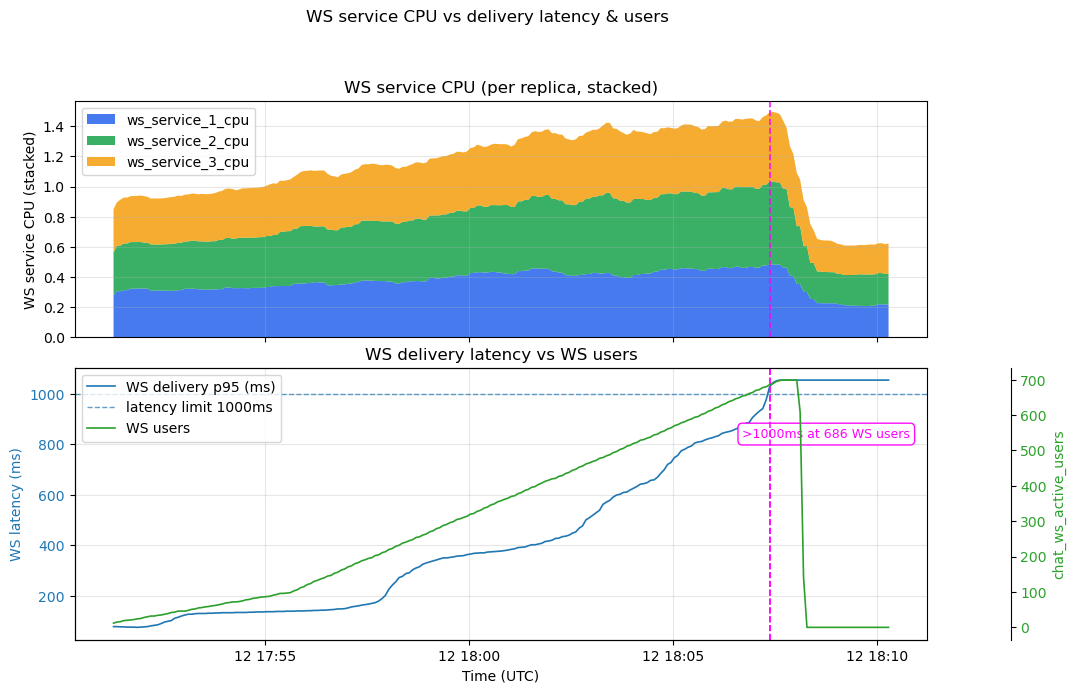

First WS p95 > 1000 ms at: 2026-05-12 18:07:21.953000069+00:00
Latency at crossing: 1027.00 ms
WS users near crossing: 686


In [39]:
import pandas as pd

colors = ["#2563EB", "#16A34A", "#F59E0B", "#EF4444", "#7C3AED"]

fig, (ax_cpu, ax1) = plt.subplots(
    2,
    1,
    figsize=(11, 7),
    sharex=True,
    gridspec_kw={"height_ratios": [1, 1.15], "hspace": 0.12},
)

# Top: per-replica ws-service CPU (EDA) stacked OR monolith app CPU when no ws-service series exist
has_ws_replicas = (
    not ws_service_1_cpu.empty
    or not ws_service_2_cpu.empty
    or not ws_service_3_cpu.empty
)


def _stack_cpu_from_frames(frames_with_labels):
    """frames_with_labels: list of (Series, str). Returns index, list of y arrays, labels."""
    if not frames_with_labels:
        return None, [], []
    series_list = [s for s, _ in frames_with_labels]
    labels = [lb for _, lb in frames_with_labels]
    df = pd.concat(series_list, axis=1, keys=labels)
    df = df.sort_index().interpolate(limit_direction="both").fillna(0.0)
    x = df.index
    ys = [df[c].to_numpy() for c in df.columns]
    return x, ys, list(df.columns)


if has_ws_replicas:
    pairs = []
    if not ws_service_1_cpu.empty:
        pairs.append((ws_service_1_cpu.iloc[:, 0], "ws_service_1_cpu"))
    if not ws_service_2_cpu.empty:
        pairs.append((ws_service_2_cpu.iloc[:, 0], "ws_service_2_cpu"))
    if not ws_service_3_cpu.empty:
        pairs.append((ws_service_3_cpu.iloc[:, 0], "ws_service_3_cpu"))

    x_cpu, ys, leg_labels = _stack_cpu_from_frames(pairs)
    if x_cpu is not None and ys:
        ax_cpu.stackplot(
            x_cpu,
            *ys,
            labels=leg_labels,
            colors=colors[: len(ys)],
            alpha=0.85,
        )
    ax_cpu.set_ylabel("WS service CPU (stacked)")
    ax_cpu.set_title("WS service CPU (per replica, stacked)")
else:
    if not monolith_app_cpu.empty:
        s_app = monolith_app_cpu.iloc[:, 0]
        x_cpu, ys, leg_labels = _stack_cpu_from_frames([(s_app, "app (monolith)")])
        if x_cpu is not None and ys:
            ax_cpu.stackplot(
                x_cpu,
                *ys,
                labels=leg_labels,
                colors=colors[: len(ys)],
                alpha=0.85,
            )
    ax_cpu.set_ylabel("App CPU (stacked)")
    ax_cpu.set_title("Monolith app CPU (stacked)")

ax_cpu.grid(True, alpha=0.3)
_h, _lab = ax_cpu.get_legend_handles_labels()
if _h:
    ax_cpu.legend(loc="upper left")

# Bottom: WS delivery latency + active users (shared time axis with top)
cross_ts = None
cross_val_ms = None
s_lat = None

if not ws_lat.empty:
    s_lat = ws_lat.iloc[:, 0]
    ax1.plot(s_lat.index, s_lat.values, color="tab:blue", linewidth=1.2, label="WS delivery p95 (ms)")
    crossed = s_lat[s_lat > 1000]
    if not crossed.empty:
        cross_ts = crossed.index[0]
        cross_val_ms = float(crossed.iloc[0])

ax1.set_ylabel("WS latency (ms)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)
ax1.axhline(y=1000, color="tab:blue", linestyle="--", linewidth=1, alpha=0.7, label="latency limit 1000ms")

ax3 = ax1.twinx()
ax3.spines["right"].set_position(("outward", 60))
if not ws_users.empty:
    s_users = ws_users.iloc[:, 0]
    ax3.plot(s_users.index, s_users.values, color="tab:green", linewidth=1.2, label="WS users")
ax3.set_ylabel("chat_ws_active_users", color="tab:green")
ax3.tick_params(axis="y", labelcolor="tab:green")

# Vertical marker when WS p95 first exceeds 1000 ms; label lower in panel (axes coords)
if cross_ts is not None:
    for ax in (ax_cpu, ax1, ax3):
        ax.axvline(cross_ts, color="magenta", linestyle="--", linewidth=1.2, alpha=0.9)
    ann_text = ">1000ms"
    if not ws_users.empty:
        s_u = ws_users.iloc[:, 0]
        nearest_idx = int(s_u.index.get_indexer([cross_ts], method="nearest")[0])
        if nearest_idx >= 0:
            users_at_cross = float(s_u.iloc[nearest_idx])
            ann_text = f">1000ms at {users_at_cross:.0f} WS users"
    ax1.text(
        0.98,
        0.78,
        ann_text,
        transform=ax1.transAxes,
        ha="right",
        va="top",
        color="magenta",
        fontsize=9,
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="white",
            edgecolor="magenta",
            linewidth=1,
            alpha=0.95,
        ),
        zorder=10,
    )

lines1, lab1 = ax1.get_legend_handles_labels()
lines3, lab3 = ax3.get_legend_handles_labels()
ax1.legend(lines1 + lines3, lab1 + lab3, loc="upper left")
ax1.set_xlabel("Time (UTC)")
ax1.set_title("WS delivery latency vs WS users")

fig.suptitle(
    "WS service CPU vs delivery latency & users"
    if has_ws_replicas
    else "Monolith app CPU vs delivery latency & users",
    y=1.01,
)
plt.tight_layout()
plt.show()

if cross_ts is None:
    print("WS delivery p95 never exceeded 1000 ms in selected range.")
else:
    print(f"First WS p95 > 1000 ms at: {cross_ts}")
    print(f"Latency at crossing: {cross_val_ms:.2f} ms")
    if not ws_users.empty:
        s_u = ws_users.iloc[:, 0]
        nearest_idx = int(s_u.index.get_indexer([cross_ts], method="nearest")[0])
        if nearest_idx >= 0:
            users_at_cross = float(s_u.iloc[nearest_idx])
            print(f"WS users near crossing: {users_at_cross:.0f}")